In [ ]:
# Mount into drive

from google.colab import drive
import matplotlib.pyplot as plt

drive.mount("/content/drive")

%cd '/content/drive/MyDrive/personal/Finalproject_singlepipeline/'


# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/personal/Finalproject_singlepipeline


In [ ]:
import os
import time
import yaml
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
!pip install torchmetrics
from torchmetrics.classification import MulticlassAccuracy, MulticlassPrecision, MulticlassRecall, MulticlassF1Score
from sklearn.metrics import confusion_matrix
from dataloader import DataLoader as MyLoader


In [ ]:
with open('config.yaml', 'r') as file:
    cfg = yaml.safe_load(file)

In [ ]:
if cfg['model']['name'].startswith('efficientnet'):
    from efficientnet import get_model
elif cfg['model']['name'].startswith('resnet'):
    from resnet import get_model
model = get_model(
    num_classes=cfg['model']['num_classes'],
    pretrained=cfg['model']['pretrained'],
    freeze_base=cfg['model']['freeze_base']
)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

Testing download...


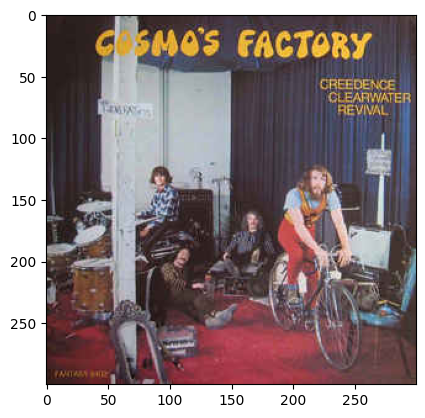

Converting data to tensors...
0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
Verifying processing...


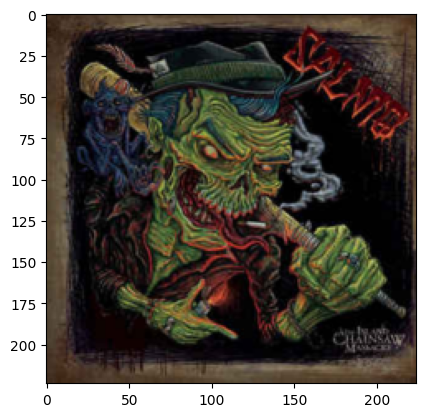

In [ ]:
dl = MyLoader(cfg)
dl.main()

train_x, train_y = dl.return_train_data()
val_x, val_y = dl.return_val_data()
test_x, test_y = dl.return_test_data()

train_dataset = TensorDataset(train_x, train_y.squeeze(1).long())
val_dataset = TensorDataset(val_x, val_y.squeeze(1).long())
test_dataset = TensorDataset(test_x, test_y.squeeze(1).long())

train_loader = DataLoader(train_dataset, batch_size=cfg['train']['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=cfg['train']['batch_size'])
test_loader = DataLoader(test_dataset, batch_size=cfg['train']['batch_size'])


In [ ]:
criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg['train']['lr'], weight_decay=cfg['train']['weight_decay'])

In [ ]:
folder_name = f"{cfg['model']['name']}_freeze={cfg['model']['freeze_base']}_{int(time.time())}"
save_dir = os.path.join('checkpoints', folder_name)
os.makedirs(save_dir, exist_ok=True)

In [ ]:
train_losses = []
val_accuracies = []
best_val_loss = float('inf')
early_stop_counter = 0

for epoch in range(cfg['train']['epochs']):
    model.train()
    total_loss = 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    train_losses.append(total_loss)

    # Validation
    model.eval()
    val_accuracy = MulticlassAccuracy(num_classes=cfg['model']['num_classes']).to(device)
    with torch.no_grad():
        val_loss = 0
        for val_images, val_labels in val_loader:
            val_images, val_labels = val_images.to(device), val_labels.to(device)
            outputs = model(val_images)
            loss = criterion(outputs, val_labels)
            val_loss += loss.item()
            val_accuracy.update(outputs, val_labels)

    acc = val_accuracy.compute().item() * 100
    val_accuracies.append(acc)

    print(f"\nEpoch [{epoch+1}/{cfg['train']['epochs']}], Train Loss: {total_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {acc:.2f}%")



model.load_state_dict(torch.load(os.path.join(save_dir, 'best_checkpoint.pt'))['model_state_dict'])
model.eval()

all_test_preds, all_test_labels = [], []
test_accuracy = MulticlassAccuracy(num_classes=cfg['model']['num_classes']).to(device)
test_precision = MulticlassPrecision(num_classes=cfg['model']['num_classes'], average='macro').to(device)
test_recall = MulticlassRecall(num_classes=cfg['model']['num_classes'], average='macro').to(device)
test_f1 = MulticlassF1Score(num_classes=cfg['model']['num_classes'], average='macro').to(device)

with torch.no_grad():
    for test_images, test_labels in test_loader:
        test_images, test_labels = test_images.to(device), test_labels.to(device)
        outputs = model(test_images)
        test_accuracy.update(outputs, test_labels)
        test_precision.update(outputs, test_labels)
        test_recall.update(outputs, test_labels)
        test_f1.update(outputs, test_labels)
        _, predicted = torch.max(outputs.data, 1)
        all_test_preds.extend(predicted.cpu().numpy())
        all_test_labels.extend(test_labels.cpu().numpy())

print(f"\nTest Accuracy: {test_accuracy.compute().item()*100:.2f}%")
print(f"Test Precision: {test_precision.compute().item()*100:.2f}%")
print(f"Test Recall: {test_recall.compute().item()*100:.2f}%")
print(f"Test F1 Score: {test_f1.compute().item()*100:.2f}%")


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title('Training Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(val_accuracies, label='Validation Accuracy', color='green')
plt.xlabel('Epochs'); plt.ylabel('Accuracy (%)'); plt.title('Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(save_dir, "loss_accuracy_plot.png"), dpi=300)
plt.show()

cm = confusion_matrix(all_test_labels, all_test_preds)
print("\nConfusion Matrix:")
print(cm)


Epoch [1/30], Train Loss: 1182.9753, Val Loss: 235.4286, Val Acc: 26.50%

Epoch [2/30], Train Loss: 1057.4981, Val Loss: 227.1454, Val Acc: 30.97%


KeyboardInterrupt: 